# 03d · Fraud Analytics Chapter 5 — Social Network Analysis for Fraud Detection
*Every concept of the chapter with explanation, worked example and code.* We first build each idea on a **toy network you can verify by hand**, then apply it to the lab bank's transaction network (labels are revealed for a random 60 % of customers — the *known* set — and every method is graded on the remaining *unknown* customers).

| # | Concept | # | Concept |
|---|---|---|---|
| 1 | Networks: form, components, characteristics, representation | 6 | Featurization summary |
| 2 | Is fraud a social phenomenon? Homophily | 7 | Community mining |
| 3 | Neighborhood metrics (degree, triangles, density, relational neighbor, probabilistic RN, relational logistic regression) | 8 | Bipartite and multipartite graphs |
| 4 | Centrality metrics (geodesics, closeness, betweenness, graph-theoretic center) | 9 | Case study: Gotcha!-style pipeline |
| 5 | Collective inference (PageRank, Gibbs, ICA, relaxation labeling, loopy BP) | | |

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, networkx as nx, scipy.sparse as sp, itertools, warnings, time
warnings.filterwarnings("ignore")
from scipy import stats
from scipy.special import logsumexp
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import amlkit as ak

pd.set_option("display.float_format", "{:,.3f}".format); pd.set_option("display.max_columns", 40); sns.set_theme(style="whitegrid"); rng = np.random.default_rng(0)
txn = pd.read_pickle(ak.PROC / "txn_clean.pkl"); feat = pd.read_pickle(ak.PROC / "features.pkl").sort_values("customer_id").reset_index(drop=True); n = len(feat); y = feat.is_launderer.values
CL = ["log_n_txn", "log_mean_amt", "log_credits", "log_amt_cash_deposit", "log_amt_wire_in", "cash_share_credits", "log_n_counterparties", "night_share", "hr_share", "log_max_cash_agg_5d", "log_turnover_ratio", "flowthrough_max", "near_ctr_cnt"]
e = txn[(txn.channel == "transfer_out") & (txn.counterparty_id >= 0) & (txn.counterparty_id < n)]
E = e.groupby(["customer_id", "counterparty_id"]).agg(cnt=("txn_id", "size"), w=("amount_usd", "sum")).reset_index(); E = E[E.customer_id != E.counterparty_id]
Gd = nx.from_pandas_edgelist(E, "customer_id", "counterparty_id", ["cnt", "w"], create_using=nx.DiGraph); Gd.add_nodes_from(range(n))
Gu = nx.Graph(); Gu.add_nodes_from(range(n))
for u, v, d in Gd.edges(data=True):
    if Gu.has_edge(u, v): Gu[u][v]["cnt"] += d["cnt"]
    else: Gu.add_edge(u, v, cnt=d["cnt"])
A = nx.to_scipy_sparse_array(Gu, nodelist=range(n), weight="cnt", format="csr").astype(float); A01 = (A > 0).astype(float).tocsr()
known = np.random.default_rng(7).random(n) < 0.6; unk = ~known; lab = np.where(known, y, -1)
print(f"lab graph: {n:,} nodes, {Gu.number_of_edges():,} undirected edges | labels known for {known.sum():,} customers ({int(y[known].sum())} suspicious); to be scored: {unk.sum():,} ({int(y[unk].sum())} suspicious)")
def auc_unknown(score): return roc_auc_score(y[unk], np.asarray(score)[unk])

lab graph: 3,500 nodes, 20,277 undirected edges | labels known for 2,066 customers (73 suspicious); to be scored: 1,434 (50 suspicious)


## 1 · Networks: form, components, characteristics, representation
**Form & applications.** A network (graph) has **nodes** (vertices: customers, companies, cards, stores…) and **edges** (links: payments, calls, shared resources), possibly **directed** and **weighted** (frequency, amount, recency). Networks power social-media, telecom (churn/viral marketing), web and **fraud** applications: *fraudsters are rarely alone* — they share resources, pay each other and copy each other's methods.

**Components.** *Egonet* = a node ("ego") plus its direct neighbours ("alters") and the links among them; *path/geodesic* = (shortest) sequence of links; *connected component* = maximal set of mutually reachable nodes; *subgraph*, *cut point/bridge*, *degree* = number of links.

**Representation.** **Adjacency matrix** A (A_ij = weight of i→j; symmetric if undirected), **edge list** and **adjacency list**; sparse storage in practice. Powers of A count paths: **(Aⁿ)_ij = number of n-hop walks from i to j**.

In [2]:
# book Fig 5.21 example: nodes A-D, links A-B, A-D, B-D, C-D
G4 = nx.Graph([("A", "B"), ("A", "D"), ("B", "D"), ("C", "D")]); nodes4 = list("ABCD")
A4 = nx.to_numpy_array(G4, nodelist=nodes4, dtype=int); print("adjacency matrix A"); print(pd.DataFrame(A4, index=nodes4, columns=nodes4))
A2 = A4 @ A4; print("A^2 = number of two-hop walks"); print(pd.DataFrame(A2, index=nodes4, columns=nodes4))
print(f"two-hop paths A->D: {A2[0, 3]} (via B) | B->D: {A2[1, 3]} (via A) | D->D: {A2[3, 3]} (D-A-D, D-B-D, D-C-D) | C->D: {A2[2, 3]}"); assert (A2[0, 3], A2[1, 3], A2[3, 3], A2[2, 3]) == (1, 1, 3, 0)
print("edge list:", list(G4.edges())); print("adjacency list:", {k: list(v) for k, v in G4.adj.items()})
Gw = nx.DiGraph(); Gw.add_weighted_edges_from([("Anna", "Maria", 5), ("Maria", "Anna", 2), ("Paul", "Lorian", 9)]); print("directed + weighted edges:", list(Gw.edges(data="weight")), "| out-degree Anna:", Gw.out_degree("Anna"), "| in-degree Anna:", Gw.in_degree("Anna"))

adjacency matrix A
   A  B  C  D
A  0  1  0  1
B  1  0  0  1
C  0  0  0  1
D  1  1  1  0
A^2 = number of two-hop walks
   A  B  C  D
A  2  1  1  1
B  1  2  1  1
C  1  1  1  0
D  1  1  0  3
two-hop paths A->D: 1 (via B) | B->D: 1 (via A) | D->D: 3 (D-A-D, D-B-D, D-C-D) | C->D: 0
edge list: [('A', 'B'), ('A', 'D'), ('B', 'D'), ('D', 'C')]
adjacency list: {'A': ['B', 'D'], 'B': ['A', 'D'], 'D': ['A', 'B', 'C'], 'C': ['D']}
directed + weighted edges: [('Anna', 'Maria', 5), ('Maria', 'Anna', 2), ('Paul', 'Lorian', 9)] | out-degree Anna: 1 | in-degree Anna: 1


connected components: 1 (largest has 3,500 nodes = 100.0%; isolated nodes: 0)


characteristics: density 0.0033 (sparse) | mean degree 11.6 | average shortest-path length ~ 3.63 (small world) | clustering coefficient 0.021


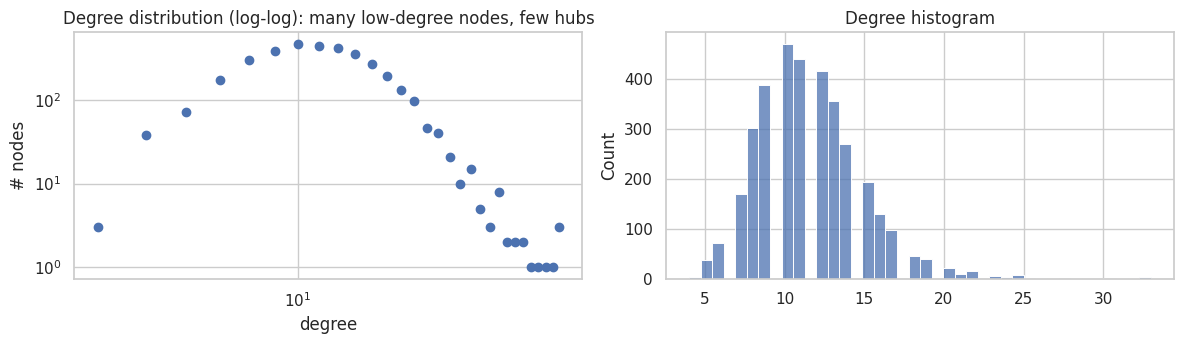

k-regular graph = every node has the same degree (degree distribution is a spike): {3}


In [3]:
comp = sorted(nx.connected_components(Gu), key=len, reverse=True); deg = np.array([d for _, d in Gu.degree()])
print(f"connected components: {len(comp)} (largest has {len(comp[0]):,} nodes = {len(comp[0]) / n:.1%}; isolated nodes: {sum(1 for c in comp if len(c) == 1)})")
Gl = Gu.subgraph(comp[0]); sp_ = [nx.average_shortest_path_length(Gl.subgraph(rng.choice(list(comp[0]), 800, replace=False).tolist())) if False else 0]
src = rng.choice(list(comp[0]), 60, replace=False); dists = np.concatenate([list(nx.single_source_shortest_path_length(Gl, s).values()) for s in src])
print(f"characteristics: density {nx.density(Gu):.4f} (sparse) | mean degree {deg.mean():.1f} | average shortest-path length ~ {dists.mean():.2f} (small world) | clustering coefficient {nx.average_clustering(Gu):.3f}")
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6)); vc = pd.Series(deg).value_counts().sort_index(); ax[0].loglog(vc.index[vc.index > 0], vc.values[vc.index > 0], "o"); ax[0].set(title="Degree distribution (log-log): many low-degree nodes, few hubs", xlabel="degree", ylabel="# nodes")
sns.histplot(deg, ax=ax[1], bins=40); ax[1].set(title="Degree histogram"); plt.tight_layout(); plt.show()
print("k-regular graph = every node has the same degree (degree distribution is a spike):", set(dict(nx.random_regular_graph(3, 20, seed=1).degree()).values()))

## 2 · Is fraud a social phenomenon? — **Homophily**
*"Birds of a feather flock together"*: linked nodes tend to share behaviour (**guilt by association**). Quantify: (a) the **assortativity coefficient** r for the fraud label, (b) **P(fraud | has a fraudulent neighbour) vs the base rate** (lift), (c) a **permutation test**: shuffle the labels over the nodes, keep the links, and see whether the observed number of fraud–fraud links is extreme. Without homophily, network features add nothing.

assortativity r = 0.062 | fraud-fraud links: observed 94 vs 24.9 +/- 4.7 under shuffled labels -> permutation p-value 0.002
P(suspicious) overall 0.035 | with >=1 suspicious neighbour 0.047 (lift 1.4x) | with none 0.027


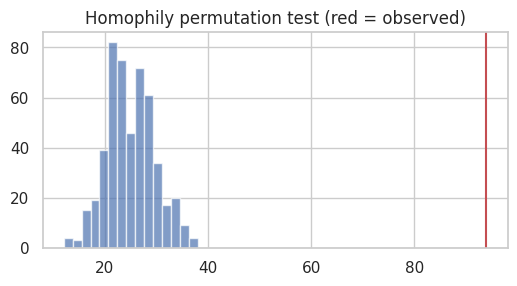

In [4]:
nx.set_node_attributes(Gu, {i: int(y[i]) for i in range(n)}, "fraud")
r_obs = nx.attribute_assortativity_coefficient(Gu, "fraud"); U = np.array(Gu.edges()); ff = int(((y[U[:, 0]] == 1) & (y[U[:, 1]] == 1)).sum())
perm = [int(((yy[U[:, 0]] == 1) & (yy[U[:, 1]] == 1)).sum()) for yy in (np.random.default_rng(s).permutation(y) for s in range(500))]
print(f"assortativity r = {r_obs:.3f} | fraud-fraud links: observed {ff} vs {np.mean(perm):.1f} +/- {np.std(perm):.1f} under shuffled labels -> permutation p-value {(np.sum(np.array(perm) >= ff) + 1) / 501:.3f}")
has_bad = (A01 @ y) > 0; print(f"P(suspicious) overall {y.mean():.3f} | with >=1 suspicious neighbour {y[has_bad].mean():.3f} (lift {y[has_bad].mean() / y.mean():.1f}x) | with none {y[~has_bad].mean():.3f}")
plt.figure(figsize=(6, 2.8)); plt.hist(perm, bins=15, alpha=.7); plt.axvline(ff, c="r"); plt.title("Homophily permutation test (red = observed)"); plt.show()

## 3 · Impact of the neighbourhood: **neighbourhood metrics**
Computed on the **egonet** (node + direct contacts), separately for **fraudulent** and **legitimate** alters:
* **Degree** — number of contacts; split into *fraudulent* and *legitimate degree*; in/out-degree for directed graphs. Real degree distributions follow a **power law**.
* **Triangles** — three mutually connected nodes; in an egonet: ego + two alters → **fraudulent** (both alters fraudulent), **semi-fraudulent** (one), **legitimate** (none). Captures group pressure.
* **Density** — observed links / possible links N(N−1)/2 of the egonet; a triangle has density 1. High fraud degree **and** high density raise the risk.
* **Relational neighbour classifier** — uses homophily: **P(c|n) = (1/Z) Σ_{n_j ∈ N(n), class(n_j)=c} w(n, n_j)**.
* **Probabilistic relational neighbour** — sums over *all* neighbours using their class **probabilities** P(c|n_j) (from a local model or a previous network model).
* **Relational logistic regression** (Lu & Getoor) — logistic model on **intrinsic** + **network** features: **mode-link** (most frequent neighbour class), **count-link** (class frequencies), **binary-link** (class present or not).

toy network: 20 nodes, 24 links; fraudulent = ['D', 'F', 'J', 'N', 'R']


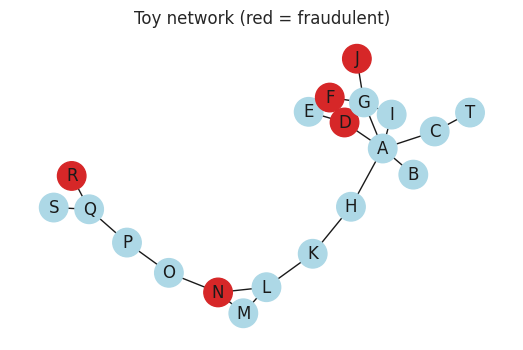

,degree,fraud_degree,legit_degree,tri_fraud,tri_semi,tri_legit,density,RN_fraud
A,6.000,1.000,5.000,0.000,1.000,1.000,0.381,0.167
B,1.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000
C,2.000,0.000,2.000,0.000,0.000,0.000,0.667,0.000
D,4.000,1.000,3.000,0.000,2.000,1.000,0.700,0.250
E,2.000,2.000,0.000,1.000,0.000,0.000,1.000,1.000
F,3.000,1.000,2.000,0.000,2.000,0.000,0.833,0.333
G,5.000,3.000,2.000,1.000,1.000,1.000,0.533,0.600
H,2.000,0.000,2.000,0.000,0.000,0.000,0.667,0.000
I,2.000,0.000,2.000,0.000,0.000,1.000,1.000,0.000
J,1.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000


triangles in the network: 5 -> A-D-G, A-G-I, D-F-G, D-E-F, L-M-N


In [5]:
# toy 20-node network (A..T) with fraudulent nodes marked; all metrics can be checked by hand
edges = [("A", x) for x in "BCDGHI"] + [("D", "E"), ("D", "F"), ("D", "G"), ("E", "F"), ("F", "G"), ("G", "I"), ("G", "J"), ("C", "T"), ("H", "K"), ("K", "L"), ("L", "M"), ("L", "N"), ("M", "N"), ("N", "O"), ("O", "P"), ("P", "Q"), ("Q", "R"), ("Q", "S")]
T = nx.Graph(edges); fraud_T = {"D", "F", "J", "N", "R"}; nodesT = sorted(T.nodes()); print(f"toy network: {T.number_of_nodes()} nodes, {T.number_of_edges()} links; fraudulent = {sorted(fraud_T)}")
pos = nx.spring_layout(T, seed=4); plt.figure(figsize=(6.5, 4)); nx.draw_networkx(T, pos, node_color=["tab:red" if v in fraud_T else "lightblue" for v in T], node_size=420); plt.axis("off"); plt.title("Toy network (red = fraudulent)"); plt.show()

def neighbourhood_table(G, fraud, weight=None):
    rows = {}
    for v in sorted(G.nodes()):
        nb = set(G[v]); fd = len(nb & fraud); ld = len(nb) - fd
        tri = [(a, b) for a, b in itertools.combinations(sorted(nb), 2) if G.has_edge(a, b)]; tf = sum(1 for a, b in tri if a in fraud and b in fraud); ts = sum(1 for a, b in tri if (a in fraud) != (b in fraud)); tl = len(tri) - tf - ts
        N_ = len(nb) + 1; M_ = len(nb) + len(tri); dens = M_ / (N_ * (N_ - 1) / 2)
        wf = sum((G[v][u].get(weight, 1) if weight else 1) for u in nb if u in fraud); wl = sum((G[v][u].get(weight, 1) if weight else 1) for u in nb if u not in fraud)
        rows[v] = dict(degree=len(nb), fraud_degree=fd, legit_degree=ld, tri_fraud=tf, tri_semi=ts, tri_legit=tl, density=dens, RN_fraud=wf / (wf + wl) if wf + wl else np.nan)
    return pd.DataFrame(rows).T
NT = neighbourhood_table(T, fraud_T); display(NT)
assert NT.loc["G", "fraud_degree"] == 3 and NT.loc["A", "degree"] == 6                         # G has 3 fraudulent contacts (D,F,J), A the highest degree
print("triangles in the network:", sum(nx.triangles(T).values()) // 3, "-> A-D-G, A-G-I, D-F-G, D-E-F, L-M-N")

In [6]:
# probabilistic relational neighbour: neighbours contribute their PROBABILITY of fraud (here from a pretend 'local model'); relational logistic features
local_p = pd.Series({v: (1.0 if v in fraud_T else 0.1) for v in T}); local_p.update({"C": 0.6, "H": 0.5, "P": 0.7})            # local-model scores (fraud nodes known = 1)
prn = {v: sum(local_p[u] for u in T[v]) / T.degree(v) for v in T}
mode_link = {v: ("F" if sum(u in fraud_T for u in T[v]) > T.degree(v) / 2 else "NF") for v in T}
rl = pd.DataFrame({"RN P(fraud)": NT.RN_fraud, "PRN P(fraud)": pd.Series(prn), "mode-link": pd.Series(mode_link), "count-link F": NT.fraud_degree, "count-link NF": NT.legit_degree,
                   "binary-link F": (NT.fraud_degree > 0).astype(int), "binary-link NF": (NT.legit_degree > 0).astype(int)}); display(rl.head(10))
print("Z (normalisation) = sum of weights of the neighbours, so probabilities sum to 1; unweighted graph -> Z = degree.")

,RN P(fraud),PRN P(fraud),mode-link,count-link F,count-link NF,binary-link F,binary-link NF
A,0.167,0.400,NF,1.000,5.000,1,1
B,0.000,0.100,NF,0.000,1.000,0,1
C,0.000,0.100,NF,0.000,2.000,0,1
D,0.250,0.325,NF,1.000,3.000,1,1
E,1.000,1.000,F,2.000,0.000,1,0
F,0.333,0.400,NF,1.000,2.000,1,1
G,0.600,0.640,F,3.000,2.000,1,1
H,0.000,0.100,NF,0.000,2.000,0,1
I,0.000,0.100,NF,0.000,2.000,0,1
J,0.000,0.100,NF,0.000,1.000,0,1


Z (normalisation) = sum of weights of the neighbours, so probabilities sum to 1; unweighted graph -> Z = degree.


In [7]:
# ---- the same metrics on the lab network, using ONLY the known labels ----
def lab_neighbourhood(A01, A, lab, local):
    kf, kl = (lab == 1).astype(float), (lab == 0).astype(float); fd, ld = A01 @ kf, A01 @ kl; unk_n = A01.sum(1) - fd - ld
    deg = A01.sum(1); tri = (A01 @ A01).multiply(A01).sum(1) / 2
    Pn = np.where(lab >= 0, lab, local); Wn = A @ Pn; Z = A.sum(1)
    Wf, Wl = A @ kf, A @ kl
    return pd.DataFrame({"deg": deg, "fraud_deg": fd, "legit_deg": ld, "unknown_deg": unk_n, "triangles": tri, "density": (deg + tri) / np.maximum((deg + 1) * deg / 2, 1),
                         "RN": np.where(Wf + Wl > 0, Wf / np.maximum(Wf + Wl, 1e-9), np.nan), "PRN": np.where(Z > 0, Wn / np.maximum(Z, 1e-9), np.nan)})
loc_model = LogisticRegression(max_iter=3000).fit(StandardScaler().fit(feat.loc[known, CL]).transform(feat.loc[known, CL]), y[known]); local = loc_model.predict_proba(StandardScaler().fit(feat.loc[known, CL]).transform(feat[CL]))[:, 1]
NB = lab_neighbourhood(A01, A, lab, local)
res = {c: auc_unknown(NB[c].fillna(NB[c].median())) for c in ["deg", "fraud_deg", "legit_deg", "triangles", "density", "RN", "PRN"]}
print("AUC on the unknown customers:", {k: round(v, 3) for k, v in res.items()}, "| local (intrinsic) model:", round(auc_unknown(local), 3))
print("share of unknown customers with >=1 known suspicious neighbour:", round((NB.fraud_deg[unk] > 0).mean(), 3), "| among them suspicious rate", round(y[unk][NB.fraud_deg[unk] > 0].mean(), 3), "vs", round(y[unk][NB.fraud_deg[unk] == 0].mean(), 3))

AUC on the unknown customers: {'deg': 0.618, 'fraud_deg': 0.56, 'legit_deg': 0.547, 'triangles': 0.586, 'density': 0.393, 'RN': 0.546, 'PRN': 0.546} | local (intrinsic) model: 0.969
share of unknown customers with >=1 known suspicious neighbour: 0.262 | among them suspicious rate 0.045 vs 0.031


In [8]:
# relational logistic regression: intrinsic + network features (count-link, binary-link, mode-link); trained on known nodes, scored on unknown nodes
def relational_features(NB):
    return pd.DataFrame({"count_F": NB.fraud_deg, "count_NF": NB.legit_deg, "binary_F": (NB.fraud_deg > 0).astype(int), "binary_NF": (NB.legit_deg > 0).astype(int), "mode_F": (NB.fraud_deg > NB.legit_deg).astype(int)})
X_int = StandardScaler().fit(feat.loc[known, CL]).transform(feat[CL]); X_rel = relational_features(NB).values; X_full = np.c_[X_int, np.log1p(X_rel[:, :2]), X_rel[:, 2:]]
m_int = LogisticRegression(max_iter=3000).fit(X_int[known], y[known]); m_rel = LogisticRegression(max_iter=3000).fit(np.log1p(X_rel[known][:, :2]), y[known]); m_all = LogisticRegression(max_iter=3000).fit(X_full[known], y[known])
print(f"AUC unknown: intrinsic only {auc_unknown(m_int.predict_proba(X_int)[:, 1]):.3f} | network-only (count-link) {auc_unknown(m_rel.predict_proba(np.log1p(X_rel[:, :2]))[:, 1]):.3f} | relational logistic regression (both) {auc_unknown(m_all.predict_proba(X_full)[:, 1]):.3f}")
print("coefficients of the network features:", dict(zip(["log count_F", "log count_NF", "binary_F", "binary_NF", "mode_F"], m_all.coef_[0][-5:].round(2))), "-> correlated network features; filter with stepwise selection as the chapter advises")

AUC unknown: intrinsic only 0.969 | network-only (count-link) 0.551 | relational logistic regression (both) 0.974
coefficients of the network features: {'log count_F': np.float64(2.63), 'log count_NF': np.float64(-0.04), 'binary_F': np.float64(-0.9), 'binary_NF': np.float64(0.0), 'mode_F': np.float64(0.0)} -> correlated network features; filter with stepwise selection as the chapter advises


## 4 · Centrality metrics
Centrality quantifies a node's **importance in the whole network** — where fraud can spread fastest or must be stopped.
* **Geodesic** = shortest path; **n-hop path counts** to fraudulent nodes (via Aⁿ).
* **Closeness**: **farness g(vᵢ) = Σ_j d(vᵢ,v_j)/(n−1)** (mean geodesic distance, self excluded); **closeness = 1/farness**. A fraudulent node with high closeness can contaminate many nodes quickly. Undefined for disconnected pairs (restrict to the component).
* **Betweenness**: **Σ_{j<k} g_jk(vᵢ)/g_jk** — share of shortest paths passing through vᵢ; brokers between communities (remove them to stop contagion).
* **Graph-theoretic centre**: the node whose **maximum distance** to any other node (eccentricity) is smallest.

In [9]:
D = dict(nx.all_pairs_shortest_path_length(T)); farness = {v: sum(D[v].values()) / (len(T) - 1) for v in T}; close = {v: 1 / farness[v] for v in T}
bet = {v: 0.0 for v in T}
for s_, t_ in itertools.combinations(T.nodes(), 2):
    paths = list(nx.all_shortest_paths(T, s_, t_))
    for v in T:
        if v not in (s_, t_): bet[v] += sum(v in p for p in paths) / len(paths)
ecc = nx.eccentricity(T); Cn = pd.DataFrame({"farness": farness, "closeness": close, "betweenness": bet, "eccentricity": ecc, "degree": dict(T.degree())})
A_T = nx.to_numpy_array(T, nodelist=nodesT); fr_idx = [nodesT.index(v) for v in sorted(fraud_T)]
for k in (1, 2, 3): Cn[f"paths_to_fraud_{k}hop"] = np.linalg.matrix_power(A_T, k)[:, fr_idx].sum(1)
Cn["geodesic_to_nearest_fraud"] = [min(D[v][f] for f in fraud_T) for v in nodesT]; display(Cn.round(3).sort_values("closeness", ascending=False).head(8))
assert np.allclose([close[v] for v in T], [nx.closeness_centrality(T)[v] for v in T]) and np.allclose([bet[v] for v in T], [nx.betweenness_centrality(T, normalized=False)[v] for v in T])
print("graph-theoretic center:", nx.center(T), "(min eccentricity =", min(ecc.values()), ") | closeness and betweenness match networkx")

,farness,closeness,betweenness,eccentricity,degree,paths_to_fraud_1hop,paths_to_fraud_2hop,paths_to_fraud_3hop,geodesic_to_nearest_fraud
A,3.211,0.311,110.833,8,6,1.000,4.000,17.000,1
H,3.211,0.311,90.000,7,2,1.000,6.000,12.000,0
K,3.316,0.302,88.000,6,2,1.000,1.000,5.000,1
L,3.526,0.284,84.000,5,3,1.000,1.000,4.000,1
G,3.789,0.264,27.167,9,5,2.000,2.000,13.000,1
D,3.842,0.260,22.667,9,4,1.000,7.000,15.000,0
N,3.895,0.257,70.000,6,3,1.000,0.000,5.000,1
I,4.000,0.250,0.000,9,2,3.000,3.000,24.000,1


graph-theoretic center: ['L'] (min eccentricity = 5 ) | closeness and betweenness match networkx


In [10]:
# lab network: closeness (pivot-sampled), betweenness (sampled), distance & path counts to KNOWN fraudsters; graded on unknown customers
Gl = nx.Graph(Gu.subgraph(comp[0])); nodes_l = np.array(sorted(Gl.nodes())); pivots = rng.choice(nodes_l, 150, replace=False)
far = np.mean([[d_.get(v, np.nan) for v in nodes_l] for d_ in (nx.single_source_shortest_path_length(Gl, p) for p in pivots[:60])], axis=0); closeness = pd.Series(1 / far, index=nodes_l).reindex(range(n))
btw = pd.Series(nx.betweenness_centrality(Gl, k=100, seed=0)).reindex(range(n)); kf_nodes = np.flatnonzero(lab == 1)
dist_f = pd.Series(nx.multi_source_dijkstra_path_length(Gu, kf_nodes.tolist())).reindex(range(n)); dist_f[kf_nodes] = np.nan
fv = (lab == 1).astype(float); paths2 = A01 @ (A01 @ fv); paths3 = A01 @ (A01 @ (A01 @ fv))          # number of 2-/3-hop walks to known fraudsters, computed by repeated matrix-vector products
CE = pd.DataFrame({"closeness": closeness, "betweenness": btw, "inv_dist_to_known_fraud": 1 / (1 + dist_f), "paths2_to_fraud": paths2, "paths3_to_fraud": paths3, "degree": deg}).fillna(0)
print({c: round(auc_unknown(CE[c]), 3) for c in CE}); print("Structural centrality (closeness/betweenness/degree) says little about being suspicious; distance and path counts TO known fraudsters carry the signal.")

{'closeness': 0.618, 'betweenness': 0.624, 'inv_dist_to_known_fraud': 0.547, 'paths2_to_fraud': 0.585, 'paths3_to_fraud': 0.623, 'degree': 0.618}
Structural centrality (closeness/betweenness/degree) says little about being suspicious; distance and path counts TO known fraudsters carry the signal.


## 5 · Collective inference algorithms
Given a **semi-labelled** network (few known frauds/legitimate, many unknown) infer a fraud probability for **all** nodes, letting inferences influence each other, so influence can travel **long distances** (unlike neighbourhood metrics). Algorithms: **PageRank** (with fraud injected through the restart vector), **Gibbs sampling**, **iterative classification**, **relaxation labelling**, **loopy belief propagation**.

**PageRank.** A *random surfer* follows a link with probability α and jumps to a random node with probability 1−α: **PR(i) = α Σ_{j→i} PR(j)/D_out(j) + (1−α)·e_i**, in matrix form **r = α·A·r + (1−α)·e** (A column-normalised, e the restart vector), solved by **power iteration** until convergence. With a **uniform** e it ranks importance; with **e = 1 on fraudulent nodes** (normalised) the score becomes a *fraud-influence* ranking (personalised PageRank).

In [11]:
def pagerank(Aw, alpha=0.85, restart=None, iters=200, tol=1e-12):
    '''Aw[i, j] = weight of link i -> j. Power iteration of r = alpha * P r + (1 - alpha) * e (dangling nodes redistribute along e).'''
    Aw = sp.csr_array(Aw, dtype=float); nn = Aw.shape[0]; out = np.asarray(Aw.sum(1)).ravel(); e_ = np.ones(nn) / nn if restart is None else restart / restart.sum()
    P = sp.diags(np.where(out > 0, 1 / np.maximum(out, 1e-300), 0)) @ Aw; r = np.ones(nn) / nn
    for it in range(iters):
        dangling = r[out == 0].sum(); r_new = alpha * (P.T @ r + dangling * e_) + (1 - alpha) * e_
        if np.abs(r_new - r).sum() < tol: r = r_new; break
        r = r_new
    return r, it + 1
# book Fig 5.23 flavour: page A is linked from B (5 links -> 1/5), C (3 links -> 1/3) and D (2 links -> 1/2)
web = {"A": ["B"], "B": ["A", "C", "D", "E", "F"], "C": ["A", "E", "F"], "D": ["A", "F"], "E": ["B"], "F": ["B", "C"]}
W = nx.DiGraph([(a, b) for a, bs in web.items() for b in bs]); order = sorted(W.nodes()); Aw = nx.to_scipy_sparse_array(W, nodelist=order)
r, iters = pagerank(Aw); ref = nx.pagerank(W, alpha=0.85, tol=1e-12); print(f"converged in {iters} iterations; max difference to networkx: {max(abs(r[i] - ref[v]) for i, v in enumerate(order)):.2e}")
print("random-surfer probabilities of moving to A next:", {p: f"1/{len(web[p])}" for p in "BCD"}, "| PageRank:", dict(zip(order, r.round(3))))
r_uniform, _ = pagerank(sp.csr_array(nx.to_numpy_array(T, nodelist=nodesT)), restart=None); e_f = np.array([1.0 if v in fraud_T else 0 for v in nodesT]); r_fraud, _ = pagerank(sp.csr_array(nx.to_numpy_array(T, nodelist=nodesT)), restart=e_f)
print(pd.DataFrame({"PageRank (importance)": r_uniform, "PageRank with fraud restart vector": r_fraud}, index=nodesT).round(3).T.to_string())

converged in 43 iterations; max difference to networkx: 2.51e-13
random-surfer probabilities of moving to A next: {'B': '1/5', 'C': '1/3', 'D': '1/2'} | PageRank: {'A': np.float64(0.158), 'B': np.float64(0.331), 'C': np.float64(0.148), 'D': np.float64(0.081), 'E': np.float64(0.123), 'F': np.float64(0.158)}
                                       A     B     C     D     E     F     G     H     I     J     K     L     M     N     O     P     Q     R     S     T
PageRank (importance)              0.110 0.023 0.046 0.069 0.037 0.053 0.088 0.041 0.038 0.022 0.042 0.061 0.043 0.063 0.047 0.050 0.080 0.030 0.030 0.027
PageRank with fraud restart vector 0.084 0.012 0.019 0.110 0.050 0.095 0.119 0.021 0.032 0.050 0.021 0.043 0.032 0.072 0.037 0.038 0.081 0.053 0.023 0.008


In [12]:
# the collective-inference family on the lab network. shared model: local prior (intrinsic) + homophily between linked nodes; known labels are fixed evidence.
Wn = A01.tocsr(); Wc = (A > 0).astype(float).tocsr(); indptr, indices = Wn.indptr, Wn.indices; Wrow = A.sum(1)
res = {}
# (a) personalised PageRank with the restart vector on KNOWN fraudsters
r_f, it = pagerank(Wc, alpha=0.85, restart=(lab == 1).astype(float)); res["personalised PageRank"] = r_f
# (b) relaxation labelling: iterate P <- (1-b)P + b * mean of neighbour probabilities, known nodes fixed
P = np.where(lab >= 0, lab, local).astype(float)
for _ in range(20): Pn = np.where(Wrow > 0, (A @ P) / np.maximum(Wrow, 1e-9), local); P = np.where(lab >= 0, lab, 0.5 * P + 0.5 * (0.5 * local + 0.5 * Pn))
res["relaxation labelling"] = P
# (c) iterative classification algorithm: local features + neighbour-label features from the CURRENT estimates, retrained each round
Pc = np.where(lab >= 0, lab, local).astype(float)
for rnd in range(5):
    nf = np.c_[(A01 @ Pc), (A01 @ (1 - Pc))]; Xi = np.c_[X_int, np.log1p(nf)]; clf = LogisticRegression(max_iter=3000).fit(Xi[known], y[known]); pn = clf.predict_proba(Xi)[:, 1]; Pc = np.where(lab >= 0, lab, pn)
res["iterative classification (ICA)"] = pn
# (d) Gibbs sampling on a pairwise Markov random field: logit P(x_i=1) = logit(prior_i) + beta * sum_j (2 x_j - 1)
beta = 0.25; prior_logit = np.log(np.clip(local, 1e-4, 1 - 1e-4) / (1 - np.clip(local, 1e-4, 1 - 1e-4))); x = np.where(lab >= 0, lab, (local > 0.5)).astype(float); cnt = np.zeros(n); r_ = np.random.default_rng(1); unk_idx = np.flatnonzero(unk); sweeps, burn = 80, 20
for s_ in range(sweeps):
    for i in r_.permutation(unk_idx):
        nb = indices[indptr[i]:indptr[i + 1]]; z = prior_logit[i] + beta * (2 * x[nb] - 1).sum(); x[i] = float(r_.random() < 1 / (1 + np.exp(-z)))
    if s_ >= burn: cnt += x
res["Gibbs sampling"] = np.where(lab >= 0, lab, cnt / (sweeps - burn))
# (e) loopy belief propagation (log-domain, damped) on the same MRF
src = np.repeat(np.arange(n), np.diff(indptr)); dst = indices; rev = np.array([np.flatnonzero((src == dst[e_]) & (dst == src[e_]))[0] for e_ in range(0)]) if False else None
key = src.astype(np.int64) * n + dst; order_ = np.argsort(key); rev = order_[np.searchsorted(key[order_], dst.astype(np.int64) * n + src)]
logphi = np.c_[np.zeros(n), prior_logit]; logphi[lab == 1] = [-10, 10]; logphi[lab == 0] = [10, -10]; logpsi = np.array([[beta, 0.0], [0.0, beta]]); M = np.zeros((len(src), 2))
for it in range(15):
    S = np.zeros((n, 2)); np.add.at(S, dst, M); cav = logphi[src] + S[src] - M[rev]                       # everything node src knows except what dst told it
    new = np.stack([logsumexp(cav + logpsi[:, [xj]].T, axis=1) for xj in (0, 1)], axis=1); new -= logsumexp(new, axis=1, keepdims=True); M = 0.5 * M + 0.5 * new
bel = logphi + np.add.reduceat(M[np.argsort(dst, kind="stable")], np.r_[0, np.cumsum(np.bincount(dst, minlength=n))[:-1]].clip(max=len(M) - 1), axis=0) if False else None
S = np.zeros((n, 2)); np.add.at(S, dst, M); bel = logphi + S; res["loopy belief propagation"] = 1 / (1 + np.exp(bel[:, 0] - bel[:, 1]))
tab = pd.DataFrame({k: dict(AUC_unknown=auc_unknown(v)) for k, v in res.items()}); tab.loc["AUC_unknown", "local model only"] = auc_unknown(local); display(tab.T.sort_values("AUC_unknown", ascending=False))

,AUC_unknown
iterative classification (ICA),0.971
local model only,0.969
loopy belief propagation,0.954
relaxation labelling,0.923
Gibbs sampling,0.778
personalised PageRank,0.583


Reading the table: on this transfer network the label evidence in the neighbourhood is thin (assortativity ≈ 0.06 in section 2), so methods that lean *only* on neighbours (Gibbs, PageRank) are weak, while methods that anchor on the local model (ICA, relaxation labelling) keep its strength and add a little. Collective inference pays off when homophily is strong and the local model is weak — check before you invest. The **shared-counterparty (bipartite) graph** of section 8 carries a stronger signal.

## 6 · Featurization: summary overview
The chapter's workflow: extract **network features** (neighbourhood + centrality + collective-inference scores) and add them to the intrinsic data set → a standard classifier (logistic regression, trees, ensembles) is trained on the *known* nodes and applied to the rest. Below, an ablation.

In [13]:
deg_ = np.asarray(A01.sum(1)).ravel(); tri_ = np.asarray((A01 @ A01).multiply(A01).sum(1)).ravel() / 2
static = pd.DataFrame({"degree": deg_, "triangles": tri_, "density": (deg_ + tri_) / np.maximum((deg_ + 1) * deg_ / 2, 1), "closeness": CE.closeness.values, "betweenness": CE.betweenness.values})
def uni_feats(vis):
    # label-dependent network features computed from the labels in `vis` only
    lv = np.where(vis, y, -1); kf, kl = (lv == 1).astype(float), (lv == 0).astype(float); Wf, Wl = A @ kf, A @ kl
    d_f = pd.Series(nx.multi_source_dijkstra_path_length(Gu, np.flatnonzero(lv == 1).tolist())).reindex(range(n))
    return pd.DataFrame({"fraud_deg": A01 @ kf, "legit_deg": A01 @ kl, "RN": np.where(Wf + Wl > 0, Wf / np.maximum(Wf + Wl, 1e-9), y[vis].mean()),
                         "inv_dist_fraud": 1 / (1 + d_f.fillna(99).values), "paths2": A01 @ (A01 @ kf) - deg_ * kf, "pagerank_fraud": np.log(pagerank(Wc, alpha=0.85, restart=kf)[0] + 1e-12)})
def oof_features(fn, K=5, seed=3):
    # Leakage guard: a TRAINING node's label-based features are computed with its own fold's labels HIDDEN (out-of-fold); nodes to be scored use all known labels.
    # Without this a fraudster 'sees itself' as its own fraudulent neighbour / restart node.
    folds = np.random.default_rng(seed).integers(0, K, n); res_ = fn(known).copy()
    for k in range(K): m = known & (folds == k); res_.loc[m, :] = fn(known & (folds != k)).loc[m, :].values
    return res_
UF = oof_features(uni_feats); FEAT = pd.concat([static, UF], axis=1)
nbh, cen, prop = ["degree", "triangles", "density", "fraud_deg", "legit_deg", "RN"], ["closeness", "betweenness"], ["inv_dist_fraud", "paths2", "pagerank_fraud"]; Xint = pd.DataFrame(X_int, columns=CL)
def fit_score(X, model="rf"):
    m = RandomForestClassifier(300, min_samples_leaf=3, class_weight="balanced_subsample", random_state=0, n_jobs=-1) if model == "rf" else LogisticRegression(max_iter=4000, C=0.3)
    Xs = StandardScaler().fit(X[known]).transform(X) if model != "rf" else X.values; m.fit(Xs[known], y[known]); return m.predict_proba(Xs)[:, 1]
sets = {"intrinsic only": Xint, "network only (all)": FEAT[nbh + cen + prop], "intrinsic + neighbourhood + centrality": pd.concat([Xint, FEAT[nbh + cen]], axis=1),
        "intrinsic + label-propagation (distance, paths, PageRank)": pd.concat([Xint, FEAT[prop]], axis=1), "intrinsic + all network features": pd.concat([Xint, FEAT[nbh + cen + prop]], axis=1)}
out = {nm: {f"AUC ({mo})": auc_unknown(fit_score(X, mo)) for mo in ("logistic", "rf")} for nm, X in sets.items()}; display(pd.DataFrame(out).T)
print("Features are built out-of-fold (see oof_features). The network adds only modestly because the intrinsic model is already strong and homophily on this graph is weak.")

,AUC (logistic),AUC (rf)
intrinsic only,0.969,0.975
network only (all),0.608,0.611
intrinsic + neighbourhood + centrality,0.973,0.983
"intrinsic + label-propagation (distance, paths, PageRank)",0.975,0.975
intrinsic + all network features,0.976,0.982


Features are built out-of-fold (see oof_features). The network adds only modestly because the intrinsic model is already strong and homophily on this graph is weak.


## 7 · Community mining: finding groups of fraudsters
A **community** is a subgraph with denser and more intensive links inside than expected by chance. Peer pressure inside a community strengthens fraud (e.g. many stolen cards used in the *same* set of stores). Techniques:

* **Graph partitioning** into a *predetermined* number of clusters by optimising the within- vs between-community links — **iterative bisection** (minimum cut, recursively) or **spectral clustering** (eigenvectors of the Laplacian). Evaluation metrics of a cut (S, T): **MinCut** = Cut(S,T) (ignores size → tends to chop off one node), **RatioCut** = Cut(S,T)·(1/|S| + 1/|T|) (balanced), **MinMaxCut** = Cut(S,T)/Cut(S,S) + Cut(S,T)/Cut(T,T) (also uses within-community links).
* **Girvan–Newman**: *divisive hierarchical* — repeatedly remove the edge with the highest **edge betweenness** (bridges between communities) → dendrogram.
* **Modularity Q** chooses the number of communities: with E the k×k matrix of the fraction of links between communities i and j and aᵢ = Σⱼ eᵢⱼ, **Q = Σᵢ (eᵢᵢ − aᵢ²)**; the best split maximises Q. (**Louvain** greedily maximises Q on large networks.)

In [14]:
Gc = nx.barbell_graph(6, 1); Gc.add_edge(0, 20); nx.set_edge_attributes(Gc, 1, "weight")               # two 6-cliques joined by a path + one pendant node (id 20)
def cut_w(G, S, Tset): return sum(1 for u, v in G.edges() if (u in S and v in Tset) or (u in Tset and v in S))
def inside(G, S): return sum(1 for u, v in G.edges() if u in S and v in S)
def cut_metrics(G, S):
    Tset = set(G) - set(S); c = cut_w(G, S, Tset); return dict(MinCut=c, RatioCut=c * (1 / len(S) + 1 / len(Tset)), MinMaxCut=c / max(inside(G, S), 1) + c / max(inside(G, Tset), 1))
cands = {"cut off the pendant node": {20}, "split the two cliques": set(range(0, 6)) | {20}}
print(pd.DataFrame({k: cut_metrics(Gc, S) for k, S in cands.items()}).T); print("MinCut prefers the trivial cut (1 link) regardless of size; RatioCut/MinMaxCut prefer the balanced, natural split.")
kl = nx.community.kernighan_lin_bisection(Gc, seed=0); print("iterative bisection (Kernighan-Lin):", [sorted(c) for c in kl])
L = nx.laplacian_matrix(Gc).toarray().astype(float); w_, v_ = np.linalg.eigh(L); fied = v_[:, 1]; nodesc = list(Gc.nodes()); print("spectral clustering (sign of the Fiedler vector):", sorted(np.array(nodesc)[fied > 0].tolist()), "|", sorted(np.array(nodesc)[fied <= 0].tolist()))

                          MinCut  RatioCut  MinMaxCut
cut off the pendant node   1.000     1.077      1.031
split the two cliques      1.000     0.286      0.125
MinCut prefers the trivial cut (1 link) regardless of size; RatioCut/MinMaxCut prefer the balanced, natural split.
iterative bisection (Kernighan-Lin): [[6, 7, 8, 9, 10, 11, 12], [0, 1, 2, 3, 4, 5, 20]]
spectral clustering (sign of the Fiedler vector): [6, 7, 8, 9, 10, 11, 12] | [0, 1, 2, 3, 4, 5, 20]


In [15]:
def modularity_Q(G, comms):
    idx = {v: i for i, c in enumerate(comms) for v in c}; k = len(comms); Em = np.zeros((k, k)); m = G.number_of_edges()
    for u, v in G.edges(): a, b = idx[u], idx[v]; Em[a, b] += 0.5 / m; Em[b, a] += 0.5 / m
    a_ = Em.sum(1); return np.trace(Em) - (a_ ** 2).sum(), Em
Gn = nx.Graph(nx.barbell_graph(6, 0)); Gn = nx.union(Gn, nx.relabel_nodes(nx.complete_graph(5), lambda i: i + 12)); Gn.add_edge(11, 12); Gn.add_edge(0, 12)     # 3 groups: two 6-cliques and one 5-clique, weakly linked
gn = nx.community.girvan_newman(Gn); rows = []
for k, part in zip(range(2, 8), itertools.islice(gn, 6)):
    comms = [set(c) for c in part]; q, _ = modularity_Q(Gn, comms); rows.append(dict(communities=k, Q_by_hand=q, Q_networkx=nx.community.modularity(Gn, comms), sizes=sorted(map(len, comms), reverse=True)))
gq = pd.DataFrame(rows).set_index("communities"); display(gq); assert np.allclose(gq.Q_by_hand, gq.Q_networkx); print("best split by modularity:", gq.Q_by_hand.idxmax(), "communities (Q =", round(gq.Q_by_hand.max(), 3), ")")
_, Em = modularity_Q(Gn, [set(c) for c in nx.community.girvan_newman(Gn).__next__()]); print("E matrix for the first split (fraction of links between communities):"); print(pd.DataFrame(Em).round(3))

,Q_by_hand,Q_networkx,sizes
communities,,,
2,0.421,0.421,"[11, 6]"
3,0.588,0.588,"[6, 6, 5]"
4,0.514,0.514,"[6, 5, 5, 1]"
5,0.449,0.449,"[6, 5, 4, 1, 1]"
6,0.401,0.401,"[6, 5, 3, 1, 1, 1]"
7,0.369,0.369,"[6, 5, 2, 1, 1, 1, 1]"


best split by modularity: 3 communities (Q = 0.588 )
E matrix for the first split (fraction of links between communities):
      0     1
0 0.349 0.023
1 0.023 0.605


In [16]:
# lab network: Louvain (maximises Q) and enrichment of suspicious customers per community (oracle used only to grade)
comms = nx.community.louvain_communities(Gu, weight=None, seed=0, resolution=1.5); comms = [c for c in comms if len(c) > 1]; q = nx.community.modularity(Gu, comms)
cm = pd.DataFrame({"size": [len(c) for c in comms], "suspicious": [int(y[list(c)].sum()) for c in comms], "known_suspicious": [int((lab[list(c)] == 1).sum()) for c in comms]}); cm["rate"] = cm.suspicious / cm["size"]
cm["p_enrichment"] = [stats.hypergeom.sf(s - 1, n, int(y.sum()), sz) for s, sz in zip(cm.suspicious, cm["size"])]; print(f"{len(comms)} communities, modularity Q = {q:.3f}"); display(cm.sort_values("p_enrichment").head(6))
comm_id = np.zeros(n, int) - 1
for i, c in enumerate(comms):
    comm_id[list(c)] = i
kn_rate = cm.known_suspicious.values / cm["size"].values; cscore = np.where(comm_id >= 0, kn_rate[comm_id], 0); print(f"community score (share of KNOWN suspicious members) AUC on unknown customers: {auc_unknown(cscore):.3f}")
# Girvan-Newman on a small neighbourhood of known suspicious customers
seeds_ = list(np.flatnonzero(lab == 1)[:6]); sub = nx.Graph(Gu.subgraph(set(seeds_) | {v for s in seeds_ for v in Gu[s]}))
if sub.number_of_nodes() > 120: sub = nx.Graph(Gu.subgraph(list(sub.nodes())[:120]))
best = max((nx.community.modularity(sub, p) , [set(c) for c in p]) for p in itertools.islice(nx.community.girvan_newman(sub), 8)); print(f"Girvan-Newman on a {sub.number_of_nodes()}-node neighbourhood: best Q = {best[0]:.3f} with {len(best[1])} communities")

59 communities, modularity Q = 0.291


,size,suspicious,known_suspicious,rate,p_enrichment
41,108,15,7,0.139,0.000
15,72,9,7,0.125,0.001
50,62,5,2,0.081,0.065
9,48,4,2,0.083,0.086
22,49,4,2,0.082,0.092
57,73,5,3,0.068,0.112


community score (share of KNOWN suspicious members) AUC on unknown customers: 0.618
Girvan-Newman on a 85-node neighbourhood: best Q = 0.689 with 7 communities


## 8 · Extending the graph: bipartite and multipartite representations
A **unipartite** graph has one node type (people–people; link weight = number of shared events). A **bipartite (affiliation) graph** adds the *events/resources* that connect them (papers, resources, claims, **stores**, counterparties): people ↔ events. It shows **why** people are connected, can carry richer **edge weights** (recency, intensity, time spent), and changes how influence flows (e.g. a triangle of people who share **one** fraudulent event is easily contaminated through that single event). It is stored as an **n × m connectivity matrix M**; the unipartite projection is **M·Mᵀ**. Fraud propagation can be **time-weighted** so that recent links carry more influence. **Multipartite** graphs add further node types (e.g. person – store – country).

In [17]:
people = ["Paul", "Lorian", "Anna", "Maria", "Elsa", "Emilio", "Gabby"]; events = ["ev1", "ev2", "ev3", "ev4"]
M0 = pd.DataFrame(0.0, index=people, columns=events)
for p, evs in {"Anna": ["ev1"], "Maria": ["ev1"], "Elsa": ["ev1", "ev4"], "Paul": ["ev2", "ev3"], "Lorian": ["ev2", "ev3", "ev4"], "Emilio": ["ev4"], "Gabby": ["ev4"]}.items(): M0.loc[p, evs] = 1
M0.loc["Maria", "ev1"] = 3.0; print("bipartite connectivity matrix M (people x events; weight = hours attended)"); print(M0)
P = (M0.values > 0).astype(int) @ (M0.values > 0).T.astype(int); np.fill_diagonal(P, 0); print("unipartite projection M M^T (number of shared events):"); print(pd.DataFrame(P, index=people, columns=people))
print("Paul & Lorian share 2 events -> stronger tie than Anna & Maria (1). ev1 fraudulent: influence reaching each person = weight / total attendance:")
fraud_ev = np.array([1, 0, 0, 0.0]); infl = (M0.values @ fraud_ev) / M0.values.sum(1); print(pd.Series(infl, index=people).round(2).to_dict(), "-> Maria (3h at the fraudulent event) is influenced more than Anna")

bipartite connectivity matrix M (people x events; weight = hours attended)
         ev1   ev2   ev3   ev4
Paul   0.000 1.000 1.000 0.000
Lorian 0.000 1.000 1.000 1.000
Anna   1.000 0.000 0.000 0.000
Maria  3.000 0.000 0.000 0.000
Elsa   1.000 0.000 0.000 1.000
Emilio 0.000 0.000 0.000 1.000
Gabby  0.000 0.000 0.000 1.000
unipartite projection M M^T (number of shared events):
        Paul  Lorian  Anna  Maria  Elsa  Emilio  Gabby
Paul       0       2     0      0     0       0      0
Lorian     2       0     0      0     1       1      1
Anna       0       0     0      1     1       0      0
Maria      0       0     1      0     1       0      0
Elsa       0       1     1      1     0       1      1
Emilio     0       1     0      0     1       0      1
Gabby      0       1     0      0     1       1      0
Paul & Lorian share 2 events -> stronger tie than Anna & Maria (1). ev1 fraudulent: influence reaching each person = weight / total attendance:
{'Paul': 0.0, 'Lorian': 0.0, 'Anna': 1

In [18]:
# lab: customers x external counterparties (shells, beneficiaries) with TIME-DECAYED weights, and a tripartite extension with destination countries
ext = txn[(txn.counterparty_id >= n) & txn.channel.isin(["transfer_out", "wire_out", "wire_in", "transfer_in"])].copy(); ext["w"] = np.exp(-(365 - ext.day) / 90)          # recent links weigh more (tau = 90 days)
cp_ids = {c: i for i, c in enumerate(sorted(ext.counterparty_id.unique()))}; m_ = len(cp_ids)
B = sp.csr_array((ext.groupby(["customer_id", "counterparty_id"]).w.sum().values, (ext.groupby(["customer_id", "counterparty_id"]).w.sum().index.get_level_values(0).values, ext.groupby(["customer_id", "counterparty_id"]).w.sum().index.get_level_values(1).map(cp_ids).values)), shape=(n, m_))
print(f"bipartite graph: {n:,} customers x {m_:,} external counterparties, {B.nnz:,} links | customers with >=1 external counterparty: {int((B.sum(1) > 0).sum()):,}")
Ab = sp.bmat([[None, B], [B.T, None]], format="csr"); restart = np.r_[(lab == 1).astype(float), np.zeros(m_)]
r_bi, _ = pagerank(Ab, alpha=0.85, restart=restart); s_bi = r_bi[:n]
Bb = (B > 0).astype(float); Ab2 = sp.bmat([[None, Bb], [Bb.T, None]], format="csr"); s_bin, _ = pagerank(Ab2, alpha=0.85, restart=restart)
proj = (Bb @ Bb.T).tocsr(); proj.setdiag(0); proj.eliminate_zeros(); s_uni, _ = pagerank(proj, alpha=0.85, restart=(lab == 1).astype(float))
print(f"AUC on unknown customers: bipartite + time-decayed weights {auc_unknown(s_bi):.3f} | bipartite binary {auc_unknown(s_bin[:n]):.3f} | unipartite projection {auc_unknown(s_uni):.3f} | direct-transfer network PageRank {auc_unknown(res['personalised PageRank']):.3f}")

bipartite graph: 3,500 customers x 4,991 external counterparties, 28,286 links | customers with >=1 external counterparty: 3,417


AUC on unknown customers: bipartite + time-decayed weights 0.728 | bipartite binary 0.695 | unipartite projection 0.708 | direct-transfer network PageRank 0.583


In [19]:
# multipartite: customers - external counterparties - destination countries (wires) : one block matrix, same propagation algorithm
wc = txn[txn.channel == "wire_out"].copy(); ctry = {c: i for i, c in enumerate(sorted(wc.country.unique()))}; g2 = wc.groupby(["customer_id", "country"]).size().reset_index(name="c")
C_ = sp.csr_array((np.log1p(g2.c.values), (g2.customer_id.values, g2.country.map(ctry).values)), shape=(n, len(ctry))); k_ = len(ctry)
Atri = sp.bmat([[None, B, C_], [B.T, None, None], [C_.T, None, None]], format="csr"); rtri, _ = pagerank(Atri, alpha=0.85, restart=np.r_[(lab == 1).astype(float), np.zeros(m_ + k_)])
print(f"tripartite graph: {n:,} customers, {m_:,} counterparties, {k_} countries | AUC unknown = {auc_unknown(rtri[:n]):.3f} (country nodes let influence flow between customers who merely wire to the same jurisdictions - useful as a feature, noisy as a link)")

tripartite graph: 3,500 customers, 4,991 counterparties, 10 countries | AUC unknown = 0.715 (country nodes let influence flow between customers who merely wire to the same jurisdictions - useful as a feature, noisy as a link)


## 9 · Case study — **Gotcha!**-style detection (social-security / tax-evasion fraud)
The chapter's case study (Van Vlasselaer et al.) targets **tax-evasion "spider constructions"**: a key company keeps founding side companies that earn revenue, skip taxes and go bankrupt; their **resources** (employees, machinery, accountants, buyers, addresses…) move to the next side company. Network view: **bipartite graph of companies and resources**; label = confirmed fraudulent companies (few); goal = fraud probability for *every other* company. **Gotcha!** combines three feature families in one model: (1) **intrinsic** features (age, sector, legal form…), (2) **direct-network** features (the egonet: the company and its current/past resources — how many are shared with fraudsters), (3) **extended-network** features from a **time-weighted propagation** of fraud influence through the bipartite graph (PageRank-style). *Below is our own compact re-implementation of that recipe on the bank data (customers ≈ companies, external counterparties ≈ resources), not the authors' code.*

In [20]:
Bk = (B > 0).astype(float).tocsr()
def bi_feats(vis):
    lv = np.where(vis, y, -1); kf = (lv == 1).astype(float); res_bad = Bk.T @ kf; res_tot = np.asarray(Bk.sum(0)).ravel(); nr = np.asarray(Bk.sum(1)).ravel(); bad_res = (res_bad > 0).astype(float); restart = np.r_[kf, np.zeros(m_)]
    return pd.DataFrame({"n_resources": nr, "resources_shared_with_fraud": Bk @ bad_res, "share_bad_resources": (Bk @ bad_res) / np.maximum(nr, 1), "fraud_customers_via_resources": Bk @ res_bad,
                         "resource_purity": (Bk @ (res_bad / np.maximum(res_tot, 1))) / np.maximum(nr, 1),
                         "influence_time_weighted": np.log(pagerank(Ab, restart=restart)[0][:n] + 1e-12), "influence_binary": np.log(pagerank(Ab2, restart=restart)[0][:n] + 1e-12)})
BF = oof_features(bi_feats)                                               # same out-of-fold protocol: no node sees its own label
groups = {"intrinsic": Xint, "direct network": BF[["n_resources", "resources_shared_with_fraud", "share_bad_resources", "fraud_customers_via_resources", "resource_purity"]],
          "extended network (propagation)": BF[["influence_time_weighted", "influence_binary"]].assign(direct_transfer_influence=FEAT.pagerank_fraud.values)}
def gotcha(cols): return auc_unknown(fit_score(pd.concat([groups[c] for c in cols], axis=1), "rf"))
abl = pd.Series({"intrinsic": gotcha(["intrinsic"]), "direct network": gotcha(["direct network"]), "extended network": gotcha(["extended network (propagation)"]),
                 "intrinsic + direct": gotcha(["intrinsic", "direct network"]), "intrinsic + extended": gotcha(["intrinsic", "extended network (propagation)"]),
                 "Gotcha-style: all three": gotcha(["intrinsic", "direct network", "extended network (propagation)"])}, name="AUC on unknown customers"); display(abl.to_frame())
sc_all = fit_score(pd.concat(list(groups.values()), axis=1), "rf"); top = np.flatnonzero(unk)[np.argsort(-sc_all[unk])[:50]]
print(f"top-50 unknown customers by the combined model: precision {y[top].mean():.0%} (base rate among unknown {y[unk].mean():.1%}); recall of the {int(y[unk].sum())} unknown suspicious customers: {y[top].sum() / y[unk].sum():.0%}")

,AUC on unknown customers
intrinsic,0.975
direct network,0.584
extended network,0.760
intrinsic + direct,0.975
intrinsic + extended,0.980
Gotcha-style: all three,0.982


top-50 unknown customers by the combined model: precision 70% (base rate among unknown 3.5%); recall of the 50 unknown suspicious customers: 70%


### Chapter 5 take-aways
* Fraud is a **social phenomenon** only if the data show **homophily** — test it (assortativity, permutation) before building network features.
* Network information enters as **features**: neighbourhood (degree, triangles, density, RN/PRN, relational logistic), centrality, **collective-inference scores** (personalised PageRank, ICA, Gibbs, relaxation labelling, LBP) and **community** membership — then a normal classifier combines them with intrinsic variables.
* **Bipartite/multipartite** graphs expose *why* nodes are linked (shared resources), allow time-weighted edges and change contagion paths.
* Evaluate with the **known/unknown label protocol**: features may use known labels of *other* nodes, never the target's own.
* Networks reveal **groups** (rings, spider constructions) that customer-by-customer models cannot see — the natural companion to the intrinsic models of chapters 3 and 4.

*Notebook 07 shows the same ideas end-to-end with permutation tests and hypergeometric community enrichment; this notebook is the concept-by-concept reference.*